In [1]:
using Pkg
Pkg.add("StatsPlots", io=devnull)
Pkg.add("DataFrames", io=devnull)
Pkg.add("CSV", io=devnull)
Pkg.add("LaTeXStrings", io=devnull)

In [2]:
using StatsPlots, DataFrames, CSV, LaTeXStrings

In [16]:
curr_dir = @__DIR__
exp_final_dir = joinpath(curr_dir, "experiments_final")
better_bounds_dir = joinpath(exp_final_dir, "better_bounds")

base_dir = better_bounds_dir

mnist_name = "mnist-global_4-5-1.0-600"

results_file = "results.csv"
csv_title = ["net", "spec", "status", "runtime", "num_propagation", "num_input_splits", "num_neuron_splits", "initial_δ_bound", "final_δ_bound"]

heuristic_variants = "DU-" .* ["Base", "Input-DiffZono"]
configs = ["DeepSplit", "LP-ZC", "VerticalSplitting", "ZonoContractInter", "ZonoContractPost", "ZonoContract"]
configs = mapreduce(c -> c * "-" .* heuristic_variants, vcat, configs)
configs = vcat(configs, "VeryDiff")
neuron_splitting_cfgs = filter(c -> !contains(c, "Input"), configs)
input_splitting_cfgs = filter(c -> c == "VeryDiff" || contains(c, "Input"), configs)

configs_paths = Dict(c => joinpath(base_dir, c) for c in configs)
mnist_paths = Dict(c => joinpath(configs_paths[c], mnist_name, results_file) for c in configs)

println("...")

...


In [17]:
cfgs_names = Dict(c => replace(c, 
        r"\-*(Base|Input|DiffZono|DU)\-*" => "", 
        "DeepSplit" => "LP", 
        "VerticalSplitting" => "VS", 
        "ZonoContract" => "ZC", 
        "Inter" => "-Inter",
        "Post" => "-Post",
    ) for c in configs)

Dict{String, String} with 13 entries:
  "ZonoContractInter-DU-Input-DiffZono" => "ZC-Inter"
  "ZonoContract-DU-Input-DiffZono"      => "ZC"
  "LP-ZC-DU-Input-DiffZono"             => "LP-ZC"
  "ZonoContract-DU-Base"                => "ZC"
  "LP-ZC-DU-Base"                       => "LP-ZC"
  "DeepSplit-DU-Input-DiffZono"         => "LP"
  "ZonoContractPost-DU-Base"            => "ZC-Post"
  "VeryDiff"                            => "VeryDiff"
  "ZonoContractInter-DU-Base"           => "ZC-Inter"
  "VerticalSplitting-DU-Base"           => "VS"
  "DeepSplit-DU-Base"                   => "LP"
  "VerticalSplitting-DU-Input-DiffZono" => "VS"
  "ZonoContractPost-DU-Input-DiffZono"  => "ZC-Post"

In [8]:
mnist_data = Dict(c => CSV.read(mnist_paths[c], DataFrame, header=csv_title, delim=", ") for c in configs)

Dict{String, DataFrame} with 13 entries:
  "ZonoContractInter-DU-Input-DiffZono" => 80×9 DataFrame…
  "ZonoContract-DU-Input-DiffZono"      => 80×9 DataFrame…
  "LP-ZC-DU-Input-DiffZono"             => 80×9 DataFrame…
  "ZonoContract-DU-Base"                => 80×9 DataFrame…
  "LP-ZC-DU-Base"                       => 80×9 DataFrame…
  "DeepSplit-DU-Input-DiffZono"         => 80×9 DataFrame…
  "ZonoContractPost-DU-Base"            => 80×9 DataFrame…
  "VeryDiff"                            => 80×9 DataFrame…
  "ZonoContractInter-DU-Base"           => 80×9 DataFrame…
  "VerticalSplitting-DU-Base"           => 80×9 DataFrame…
  "DeepSplit-DU-Base"                   => 80×9 DataFrame…
  "VerticalSplitting-DU-Input-DiffZono" => 80×9 DataFrame…
  "ZonoContractPost-DU-Input-DiffZono"  => 80×9 DataFrame…

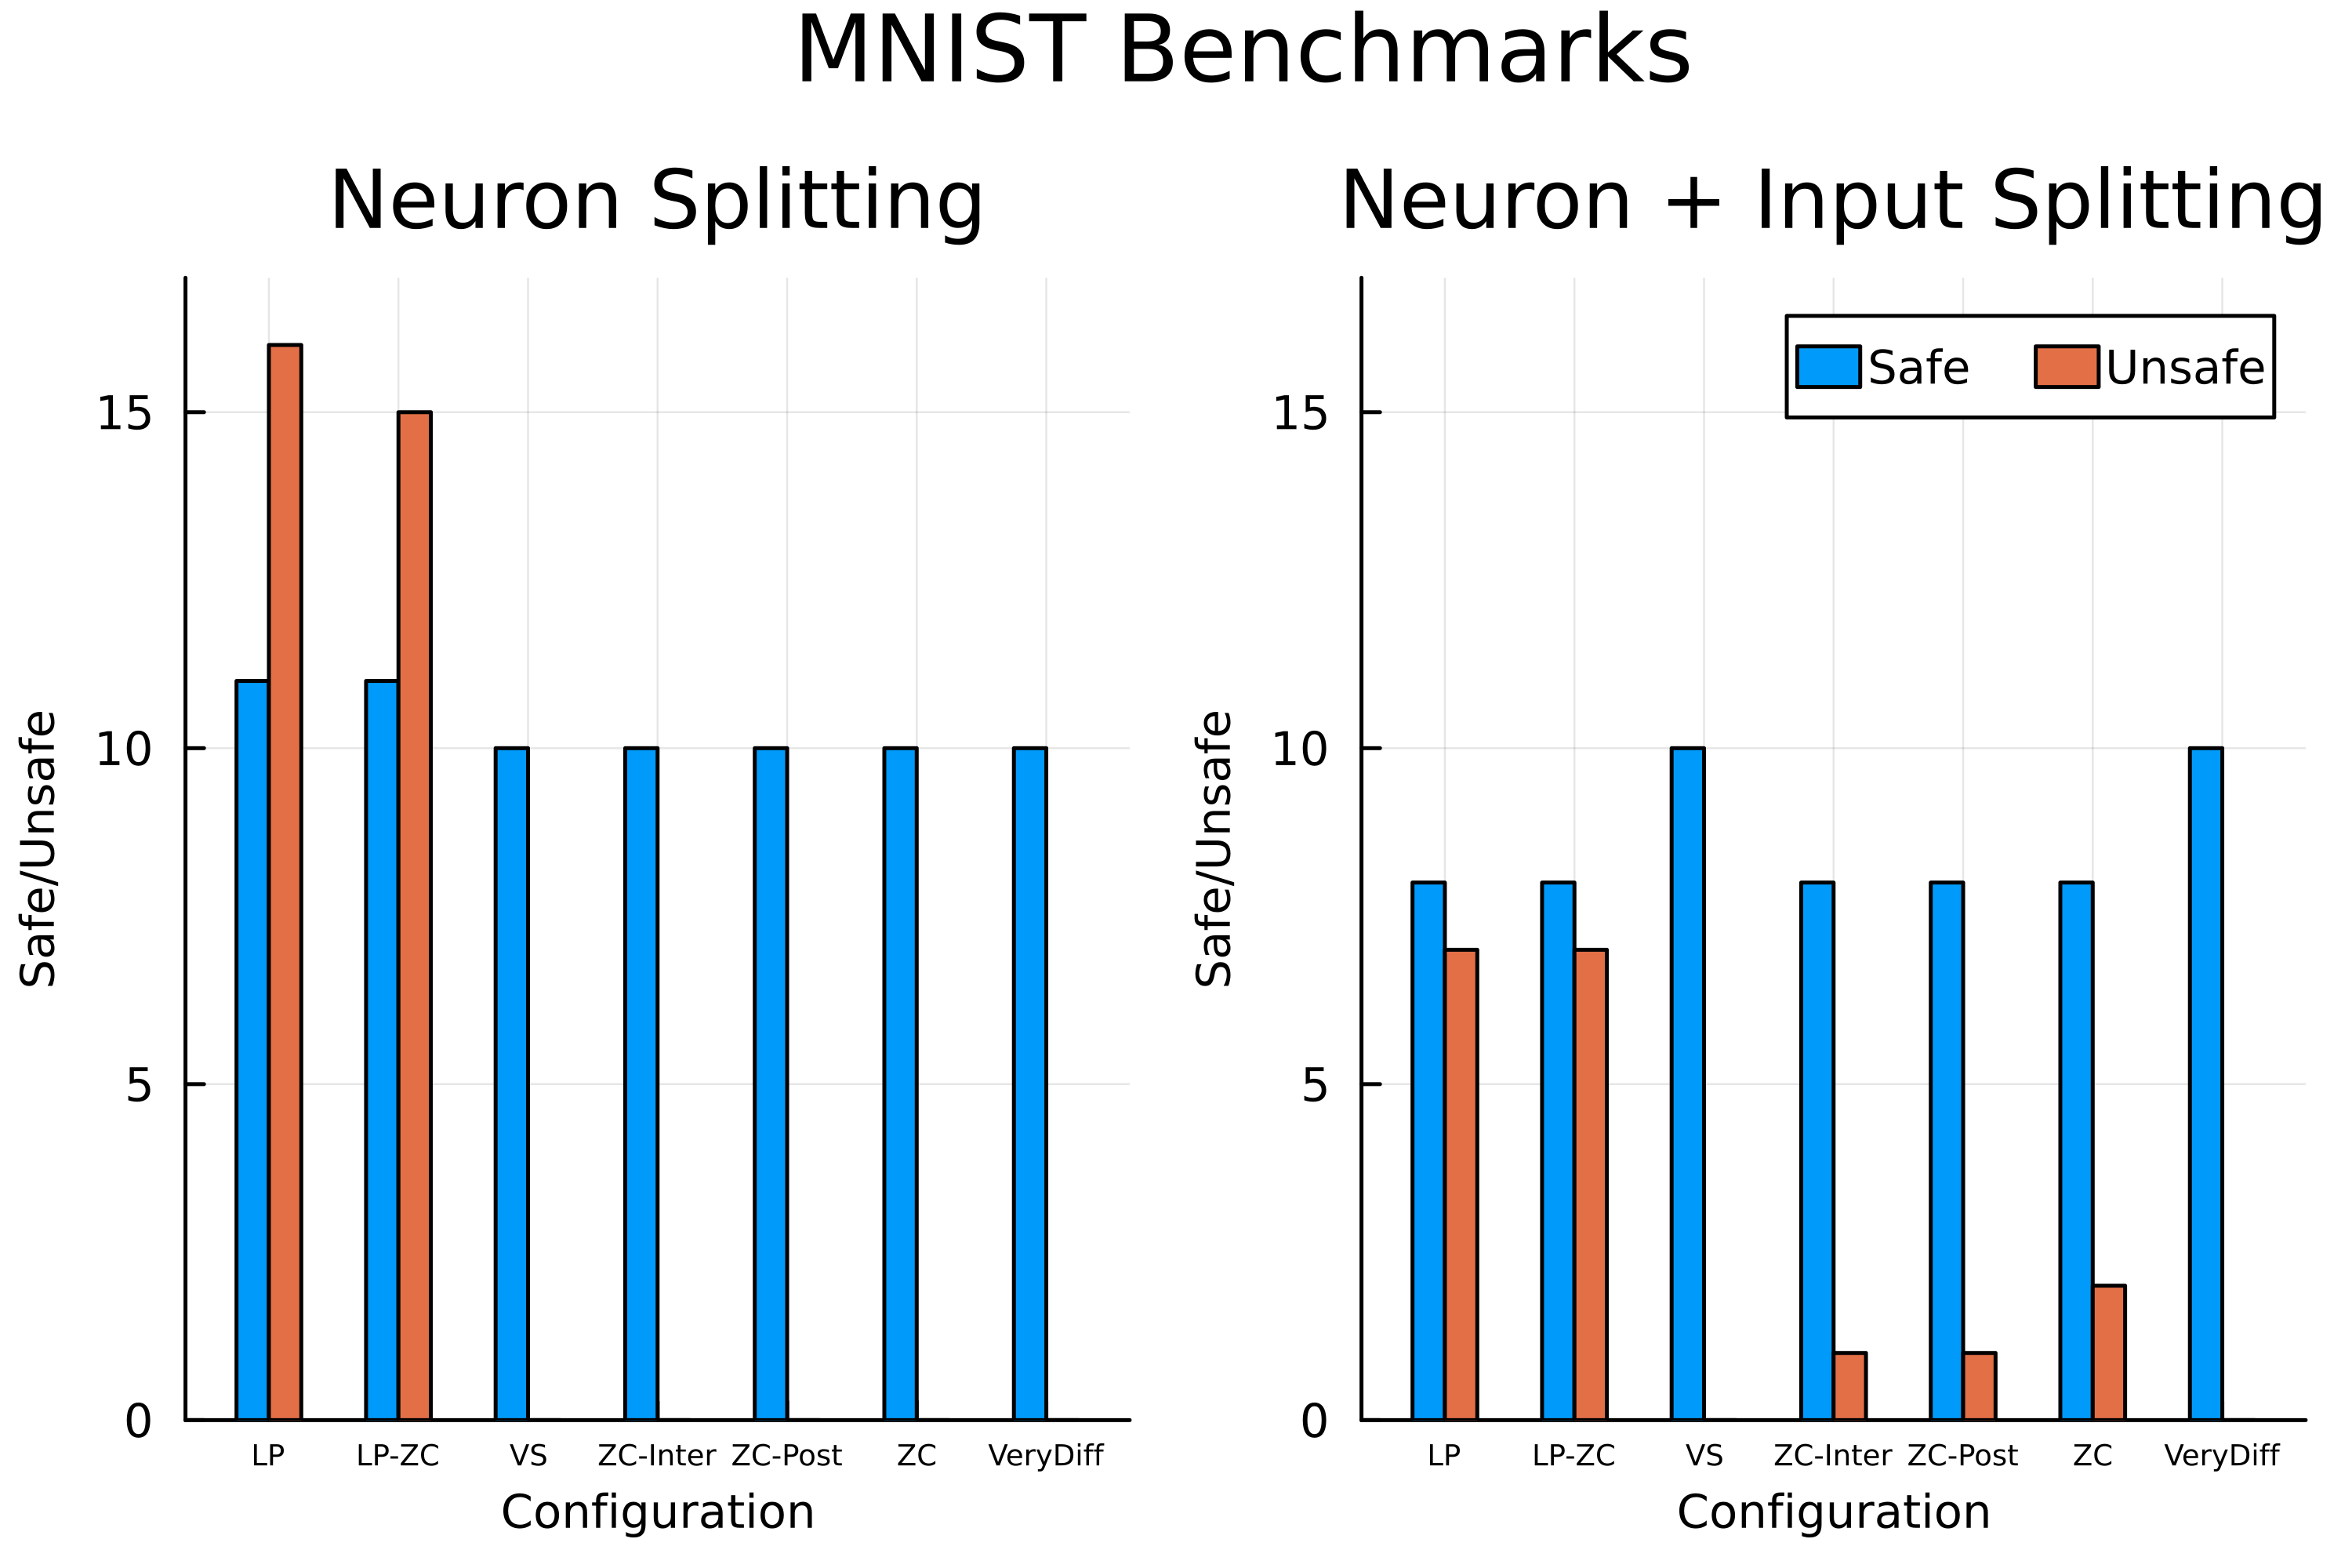

In [9]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, widen=true, legend=false, xlabel="Configuration", ylabel="Safe/Unsafe"; layout=2)

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
max_y = 0

for (i, cfgs) in enumerate(all_cfgs)
    num_safe = map(c -> count(s -> s == "SAFE", mnist_data[c].status), cfgs)
    num_unsafe = map(c -> count(s -> s == "UNSAFE", mnist_data[c].status), cfgs)
    names = map(c -> cfgs_names[c], cfgs)

    max_y = max(max_y, maximum(num_safe), maximum(num_unsafe))

    groupedbar!(p, names, [num_safe num_unsafe], label=["Safe" "Unsafe"], title=titles[i], bar_position=:dodge, lw=1.0, bar_width=0.5, subplot=i)
end

plot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
plot!(p, legend=:topright, legendcolumns=2, subplot=2)
plot!(p, ylims=(0, max_y+1))

# savefig(p, "$eval_mnist_dir/$(mnist_out_name)-hist.pdf")

p

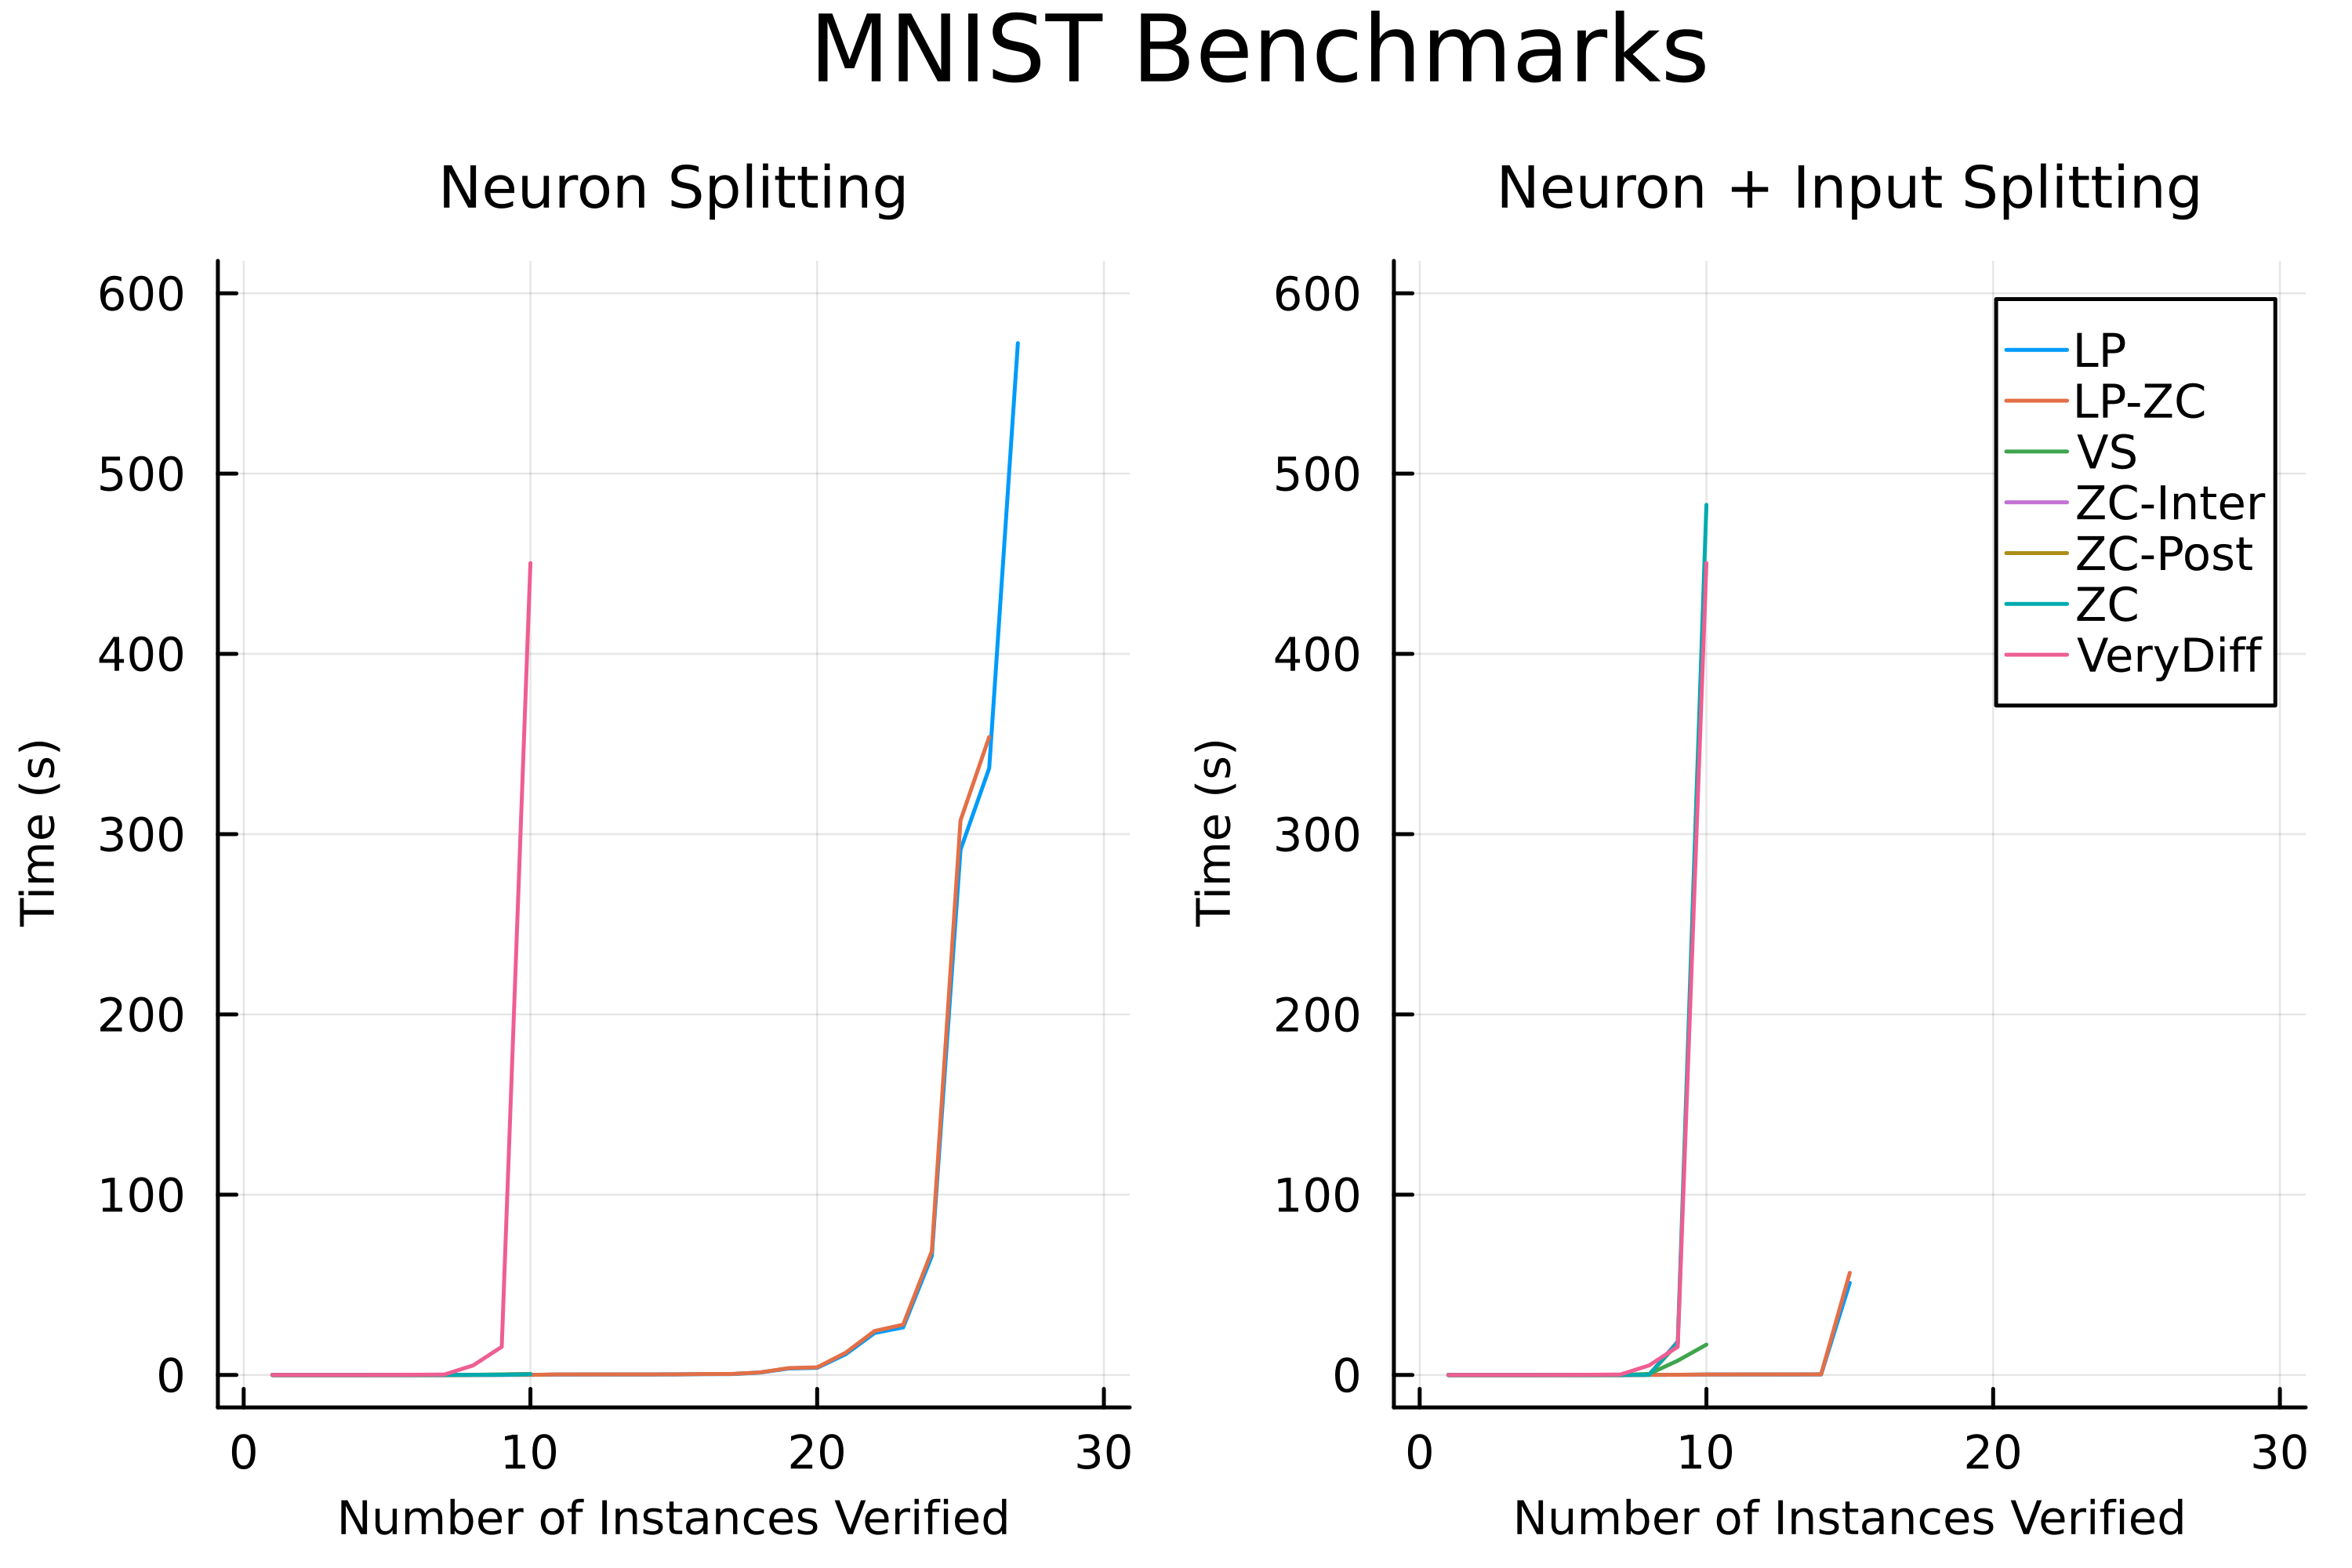

In [12]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 30), ylims=(0, 600), widen=true, titlefontsize=10, xguidefontsize=8, yguidefontsize=8, legend=false; layout=2)
xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    runtimes = map(c -> c.runtime / 1e9, filter.(c -> c.status != "UNKNOWN", map(c -> mnist_data[c], cfgs)))
    runtimes = sort.(runtimes)
    for (j, runtime) in enumerate(runtimes)
        plot!(p, runtime, title=titles[i], label=cfgs_names[cfgs[j]], subplot=i)
    end
end

plot!(p, subplot=2, legend=:topright)
plot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, "$eval_mnist_dir/$(mnist_out_name).pdf")

p

In [13]:
function δ_bound_improvement(inst, target)
    ifelse(inst.status .!= "UNKNOWN", 1.0, (inst.initial_δ_bound - inst.final_δ_bound) / (inst.initial_δ_bound - target))
end

δ_bound_improvement (generic function with 1 method)

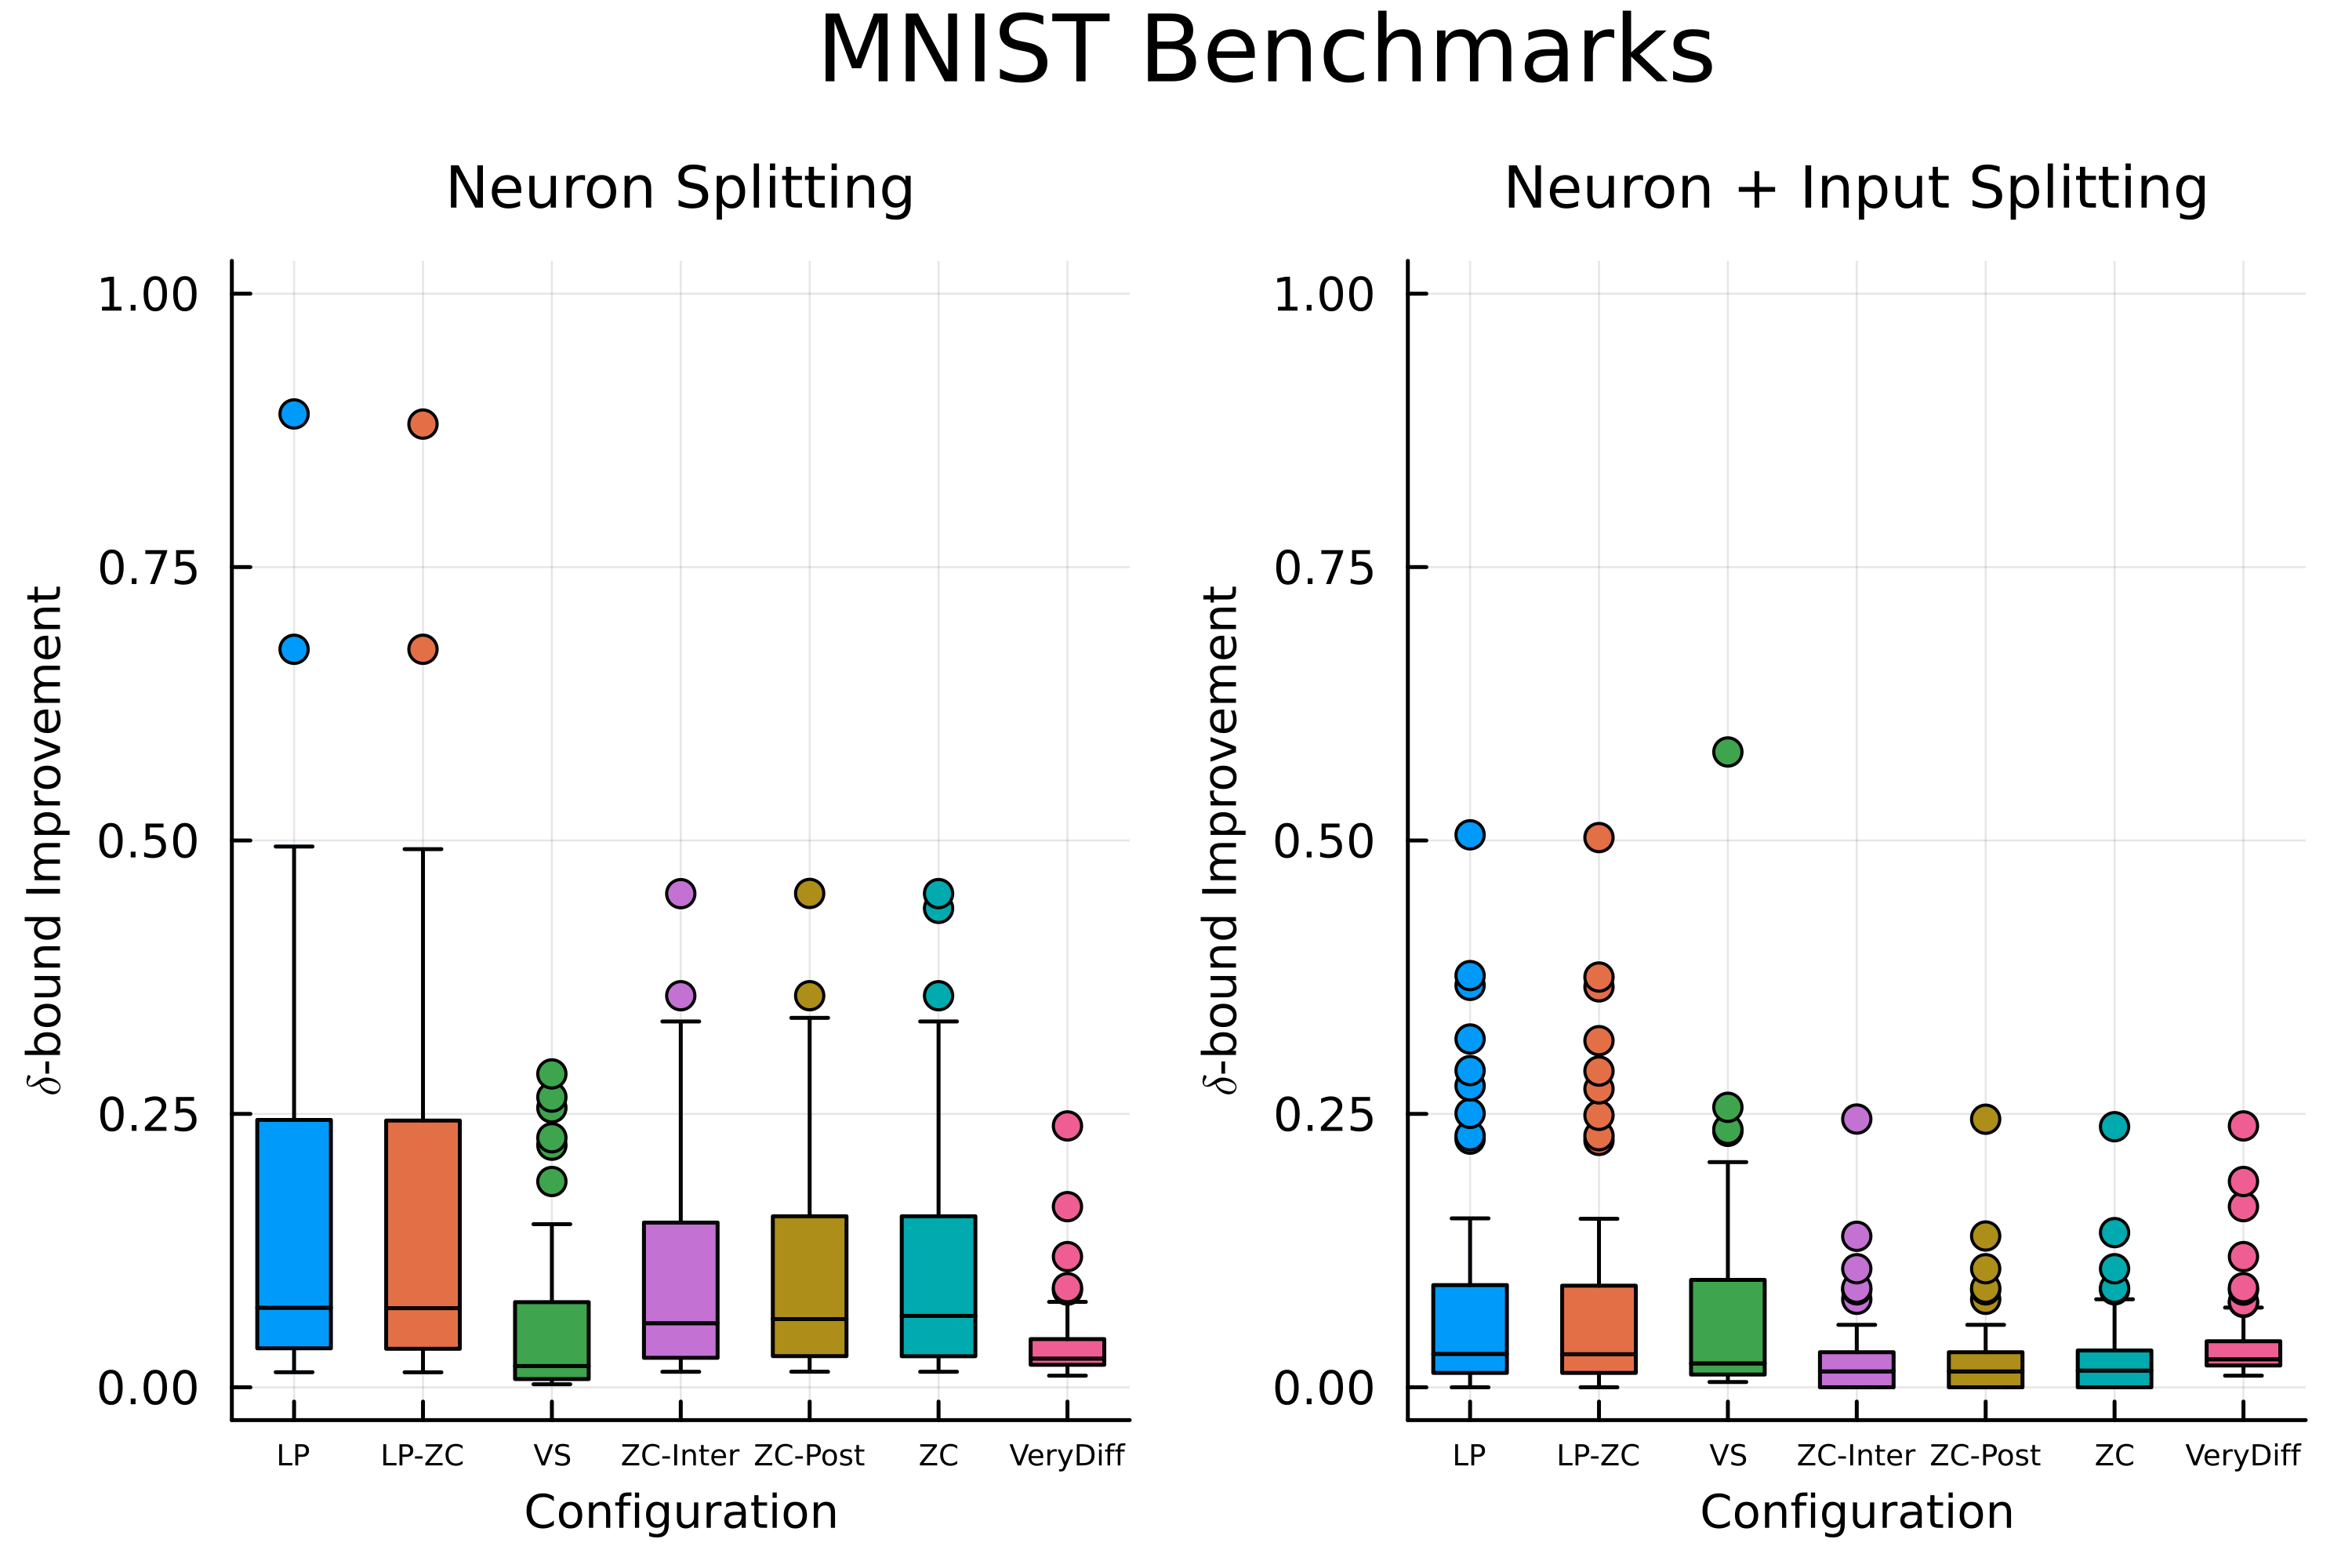

In [14]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
num_cfgs = size(all_cfgs, 1)
p = boxplot(dpi=500, widen=true, titlefontsize=10, xguidefontsize=5, yguidefontsize=5, legend=false; layout=num_cfgs)
xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    unsolved_mask = mapfoldl(c -> mnist_data[c].status .== "UNKNOWN", (x, y) -> x .&& y, cfgs)
    improvements = mapreduce(cfg -> sort(δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfg][unsolved_mask, :]), 1.0)), hcat, cfgs)
    boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, title=titles[i], subplot=i)
end

ylims!(0, 1)
boxplot!(p, subplot=1, legend=false)
boxplot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
boxplot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, "$eval_mnist_dir/bt-$(mnist_out_name)-boxplot.pdf")

p

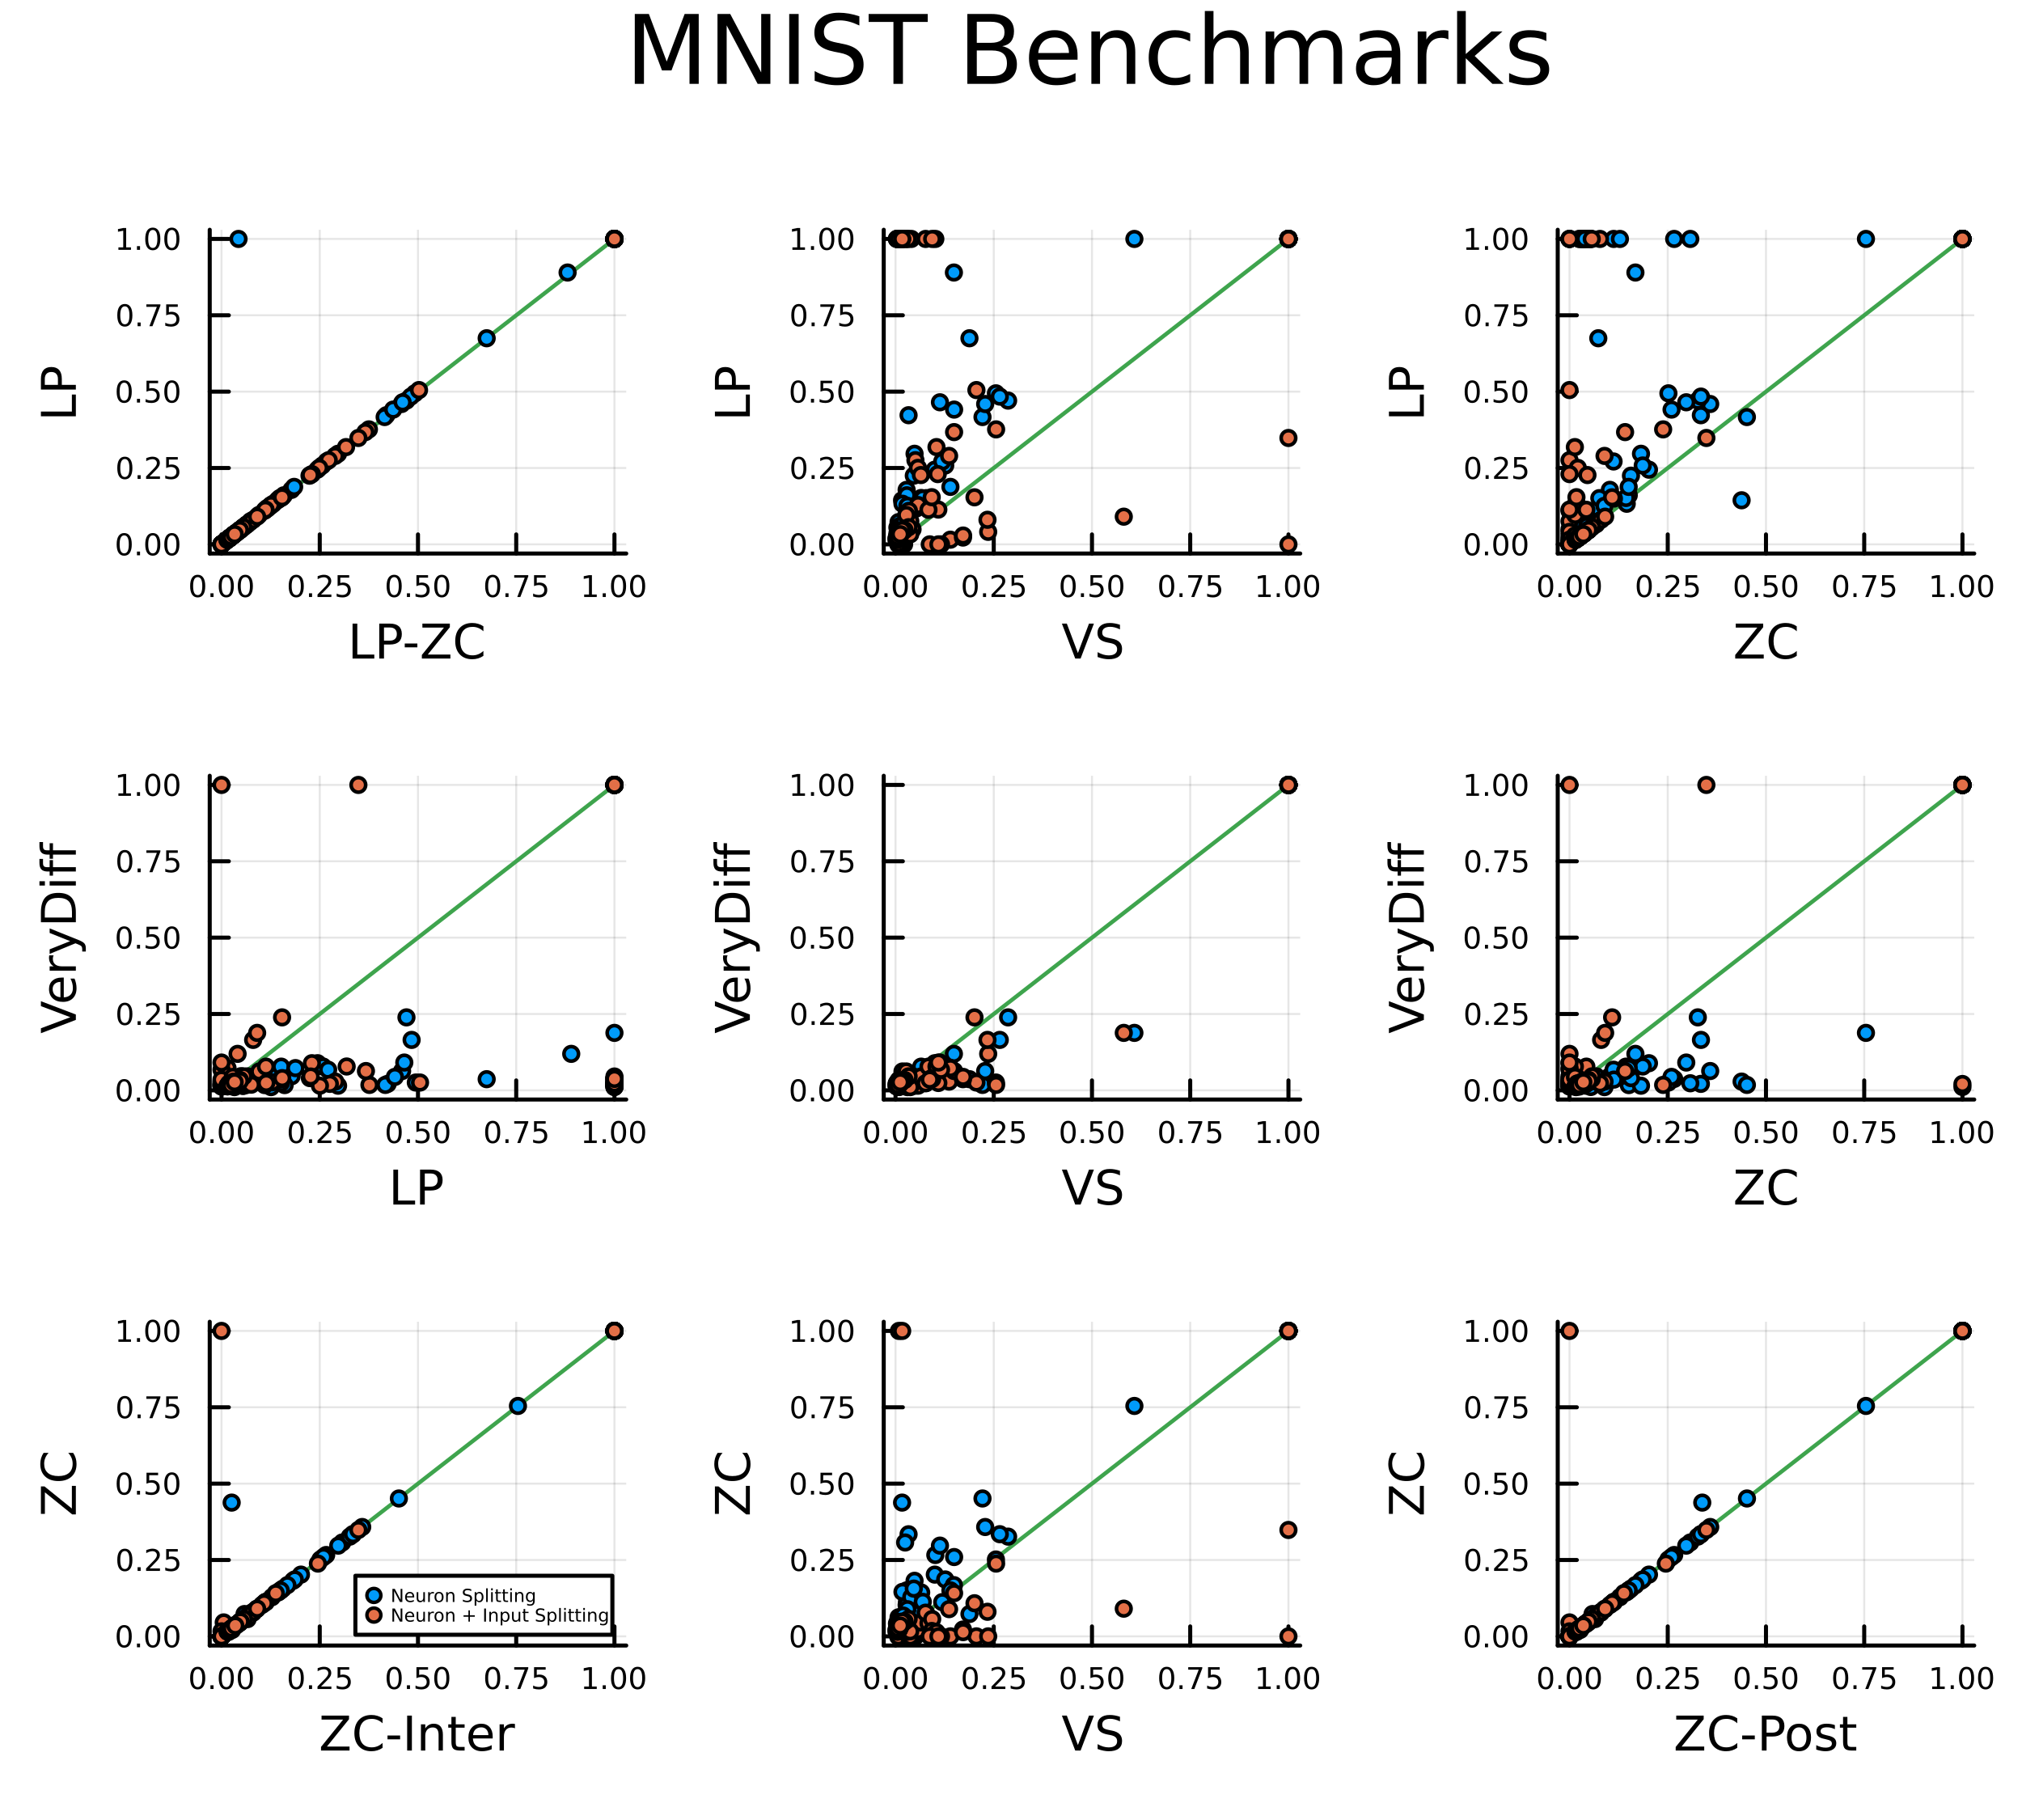

In [15]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 1), ylims=(0, 1), widen=true, legend=false, label=false; layout=grid(3, 3), size=(500, 450))

labels = ["Neuron Splitting" "Neuron + Input Splitting"]
combinations = [(2, 1), (3, 1), (6, 1), (1, 7), (3, 7), (6, 7), (4, 6), (3, 6), (5, 6)]

for (n, (i, j)) in enumerate(combinations)
    plot!(p, range(0, 1), range(0, 1), label=false, c=3, subplot=n)

    for (k, cfgs) in enumerate(all_cfgs)
        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)
        
        y₁ = δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfgs[i]]), 1.0)
        y₂ = δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfgs[j]]), 1.0)

        scatter!(p, y₁, y₂, markersize=2.0, label=labels[k], c=k, subplot=n)
    end
end

scatter!(p, subplot=7, label=labels, legend=:bottomright)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5, ytickfontsize=5, legendfontsize=3)
plot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, "$eval_mnist_dir/bt-$(mnist_out_name)-bounds.pdf")

p